# Assignment 2 -  Extended Kalman filter and Unscented Kalman filter


- **Topic:** Desiging an EKF and UKF to estimate the position using magnetic field information
- **Assessment:** The assignment will go through a pass/fail check.


- **Deadline:**  07-03-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment2_groupNumber.ipynb` TO BRIGHTSPACE**, where groupNumber is your groupnumber



## Instructions
**Installation:** The implementation is tested with python 3.9.12 and packages including
-   numpy version: 1.26.4
-   scipy version: 1.13.0
-   matplotlib version: 3.5.1


Other (not too old or new) versions will probabily also work.

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.



## AI Related Policy
We strongly discourage you to use AI tools for implementation assistance. It is your understanding of the problem that is tested in the final exam.


## Information
Please fill in your group number, names and student numbers in the cell below.

<!-- first EKF and then UKF, very similar to normal KF-->

In [1]:
groupNumber = 30

STUDENT_1_NAME = "Josephine King"
STUDENT_1_STUDENT_NUMBER = "6250513"

STUDENT_2_NAME = "Joost Jaspers"
STUDENT_2_STUDENT_NUMBER = "5372925"

# raise NotImplementedError()

## Objectives

#### Goal

The goal of this assignment is to estimate the position $ \mathbf{p}_t $ of an agent, the same as assignment 1, but using different algorithmns. The agent moves in an indoor environment and gets information about its approximate change in position $ \Delta \mathbf{p}_t $ at every time-step. To model this, you may assume a linear dynamic model of the form:
$$\mathbf{p}_{t + 1} = \mathbf{p}_t + \Delta \mathbf{p}_{t+1} + \mathbf{w}_{t+1}$$

Where:

- $\mathbf{p}_t$ is a 3-dimensional position vector of the agent at time $t$. 

- $\Delta \mathbf{p}_t$ is the change in positon.

- $\mathbf{w}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{Q})$ is Gaussian white noise.

- $ \mathbf{Q} \in \mathbb{R}^{3 \times 3} $ is the covariance of the process noise.

Since the information of the change in position $ \Delta \mathbf{p}_t$ contains errors, the position estimates from the dynamic model will drift. This means that over time, the agent will lose track of where it actually is. To remedy this, the agent is carrying a magnetometer, and has a map of the magnetic field. The magnetometer samples a measurement of the magnetic field $\mathbf{y}_t$ at every position $\mathbf{p}_t$. The map of the magnetic field is modeled by a non-linear function: a reduced rank Gaussian process (you do not need to understand, model or change the GP model, only to call the function evaluation). This results in the non-linear measurement model:
$$ \mathbf{y}_t = f(\mathbf{p}_t) + \mathbf{v}_t $$

Where:

- $\mathbf{y}_t$ is a 3-dimensional measurement vector of the magnetic field at time-step $t$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\mathbf{v}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{R})$ is Gaussian white noise.

- $ \mathbf{R} \in \mathbb{R}^{3 \times 3} $ is the covariance of the measurement noise.


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the magnetometer measurements
- `magnetometerInitialPosition` $\in \mathbb{R}^{3 \times 1}$ is a numpy array containing the initial position of the magnetometer
- `deltaMagnetometerPositions` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the change in position of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the EKF and UKF you DO NOT need this dictionary.

In [2]:
''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt

import GP as GP
import linAlg as linAlg
import helper as helper
np.random.seed(groupNumber)

(magnetometerMeasurements, 
 magnetometerInitialPosition, 
 deltaMagnetometerPositions,
 modelParameters) = helper.initializeKalmanFilterAssignment(groupNumber % 29)


Same as the first assignment of particle filter, below, a function `helper.makeDeadReckoningPlots()` is given to plot the map of the magnetic field and the ground truth position of the path taken by the agent. The agent does not know this path, it only has access to its initial position, the change in position at every time-step and the magnetometer measurements. You can reuse the code for the plots.

Your first task it to use the agent's dynamic model to try and reconstruct the ground truth path. This is also known as dead reckoning and should be done using data stored in the variables `magnetometerInitialPosition` and `deltaMagnetometerPositions`. Save the agent's positions according to the dynamic model in the variable `deadReckoning` $\in \mathbb{R}^{3 \times \text{T}}$. Additionally, compare the magnetometer measurements with the map of the magnetic field. To achieve this, store the norm of the magnetic field at every time-step in the variable `magneticFieldNorm` $\in \mathbb{R}^{\text{T}}$.

This function should output two subfigures. Every subfigure includes the magnetic field map in the background. On the left the ground truth positions are plotted together with the dead reckoning positions. On the right, the magnetic field measurements are plotted with  the ground truth positions over the magnetic field map.

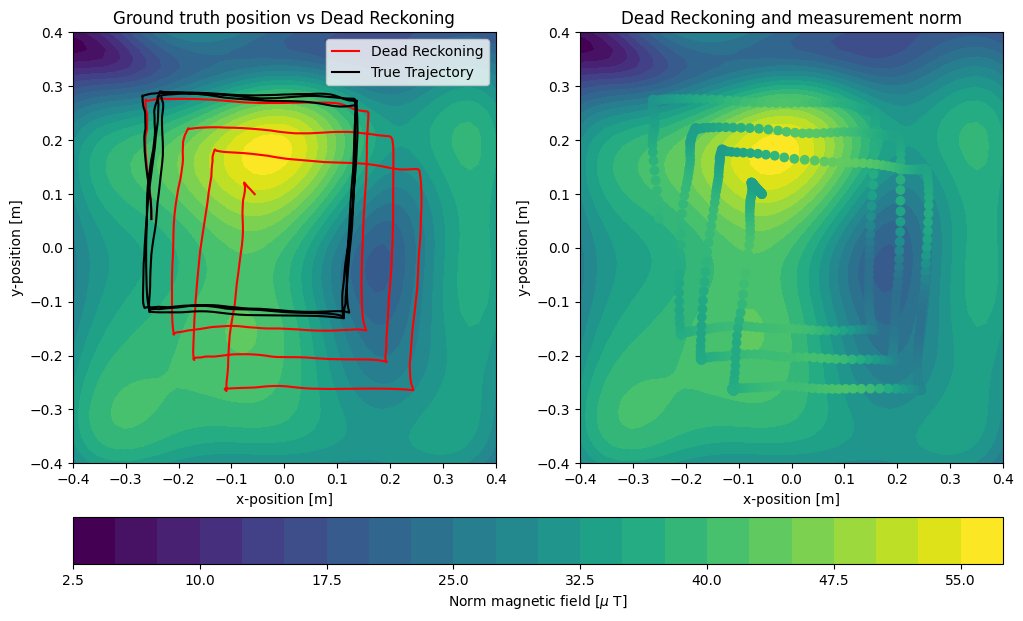

In [33]:
N = deltaMagnetometerPositions.shape[1]
deadReckoning = np.zeros((3, N+1))
magneticFieldNorm = np.zeros((1, N))

# Loop through all the measurements to calculate the deadReckoning positions an magneticFieldNorm values
deadReckoning[:,0] = magnetometerInitialPosition.flatten()
for i in range(0,N):
    delta = deltaMagnetometerPositions[:,i]
    deadReckoning[:,i+1] = deadReckoning[:,i] + delta
    magneticFieldNorm[:,i] = np.linalg.norm(magnetometerMeasurements[:,i])

# Remove the initial position
deadReckoning = deadReckoning[:,1:N+1]


helper.makeDeadReckoningPlots(deadReckoning, magneticFieldNorm, modelParameters)

## EKF and UKF
To  use magnetometer measurements to reduce the positional drift observed in the figure above, besides PF in the previous lectures, you can also use EKF and UKF.

### EKF Implementation

You start from implementing EKF.  Your task is to fill in the following functions.

#### Task 1
Fill in the `dynamicUpdateEKF()` function according to the dynamic model given above. 

**Note:**
You do not have to change the inputs and outputs to the given functions.


In [191]:

def dynamicUpdateEKF(position, 
                   deltaPos, 
                   posCov, 
                   motionCovarianceEKF, 
                   modelParameters):
    ''' Dynamic update '''
    position = position + deltaPos    
    posCov = posCov + motionCovarianceEKF

    return position, posCov



#### Task 2

Complete the function `measurementUpdateEKF()` according to the measurement model given above. 

To implement the measurement model, you will need to make predictions of the magnetic field. You DO NOT need to create this function yourself. To make predictions, use the function `GP.makeMagneticFieldPrediction(positions, modelParameters)` function make sure the input `positions` $\in \mathbb{R}^{3 \times 1} $. The output should be a matrix $\in \mathbb{R}^{3 \times 1}$ magnetic field predictions for every input location.  Similarly, to find the Jacobian, you muse use the GP.makeMagneticFieldJacobian(position, modelParameters) function make sure the input position is a vector of 3x1. The output should be a matrix of 3x3.

In [192]:
def measurementUpdateEKF(position, 
                         magnetometerMeasurement, 
                         posCov, 
                         measurementCovarianceEKF,
                         modelParameters):
    
    ''' Measurement update '''

    magneticFieldPrediction = GP.makeMagneticFieldPrediction(position, modelParameters) 
    jacobianMagneticFieldPrediction = GP.makeMagneticFieldJacobian(position, modelParameters)
    H = jacobianMagneticFieldPrediction

    K = posCov@H.T@np.linalg.inv(H.T@posCov@H.T + measurementCovarianceEKF)
    position = position + K@(magnetometerMeasurement - magneticFieldPrediction)

    posCov = posCov - K@H@posCov

    return position, posCov

`extendedKalmanFilter()` is given as follows. You don't need to change it.

In [193]:
''' DO NOT CHANGE THE CODE BELOW '''

def extendedKalmanFilter(position, 
                         deltaPosition, 
                         magnetometerMeasurement, 
                         posCov, 
                         motionCovarianceEKF, 
                         measurementCovarianceEKF, 
                         modelParameters):
    ''' Estimates positions'''

    ''' Dynamic update '''    
    if modelParameters['NtimeStepEKF'] > 0:
        (position, 
         posCov) = dynamicUpdateEKF(position, 
                                  deltaPosition, 
                                  posCov, 
                                  motionCovarianceEKF,
                                  modelParameters)

    ''' Measurement update '''
    (position, 
     posCov) = measurementUpdateEKF(position,
                                    magnetometerMeasurement, 
                                    posCov, 
                                    measurementCovarianceEKF,
                                    modelParameters)

    return position, posCov


#### Task 3

Be sure to set the **initial position** and the **prior** on it correctly  and a **suitable measurement covariance** as you did in assignment 1.

You could start with the following parameters
- `motionCovarianceUKF` = np.eye(3)*0.001**2 
- `measurementCovarianceUKF` = np.eye(3)*1.5**2

Make sure `posCovarianceUKF` is a 3d tensor with the shape of `[3,3,NtimeSteps]`, to save the position covariances for every time step.
To get better results, you might have to tune these. 

In [204]:
''' Initialize the EKF '''
modelParameters['NtimeStepEKF'] = 0

motionCovarianceEKF = np.eye(3)*0.001**2 
measurementCovarianceEKF = np.eye(3)*1.5**2

posEstEKF = np.zeros((3, modelParameters['NtimeSteps']))
posCovarianceEKF = np.zeros((3, 3, modelParameters['NtimeSteps']))
posEstEKF[:,0] = magnetometerInitialPosition.squeeze()
# How to initialize the covariance matrix?
posCovarianceEKF[:,:,0] = np.eye(3)*0.1

''' Run the EKF'''
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosEKF = deltaMagnetometerPositions[:, timendx:timendx+1]
    ymeasEKF = magnetometerMeasurements[:, timendx:timendx+1]
    (posEstEKF[:, timendx+1:timendx+2], 
     posCovarianceEKF[:, :, timendx+1]) = extendedKalmanFilter(posEstEKF[:, timendx:timendx+1], 
                                              deltaPosEKF, 
                                              ymeasEKF, 
                                              posCovarianceEKF[:, :, timendx],
                                              motionCovarianceEKF,
                                              measurementCovarianceEKF,
                                              modelParameters)
    modelParameters['NtimeStepEKF'] += 1

#### discussion

Elaborate on the effects of tuning the different variables:

- `motionCovarianceEKF`

If we increase the motion covariance, the estimate is based more on the measurements and the trajectory is very off, especially on the top and bottom of the square. The covariance ellipses are also bigger. If we decrease the motion covariance, the trajectory looks more like the deadReckoning trajectory and the covariance ellipses get smaller. 

- `measurementCovarianceEKF`

If we increase the measurement covariance, the estimate is based more on the dynamic model and the trajectory looks more like the dead reckoning. The covariance ellipses get bigger. If we decrease the motion covariance, the trajectory is based more on the measurement and doesn't drift over time but is quite off on the top and bottom of the trajectory. The covariance ellipses also get smaller.     

- The initial posiiton covariance `posCovarianceEKF[:, :, 0]`


#### Visualize the output
<!-- TODO: keep or not. maybe comparison between EKF and UKF in the end is enough -->

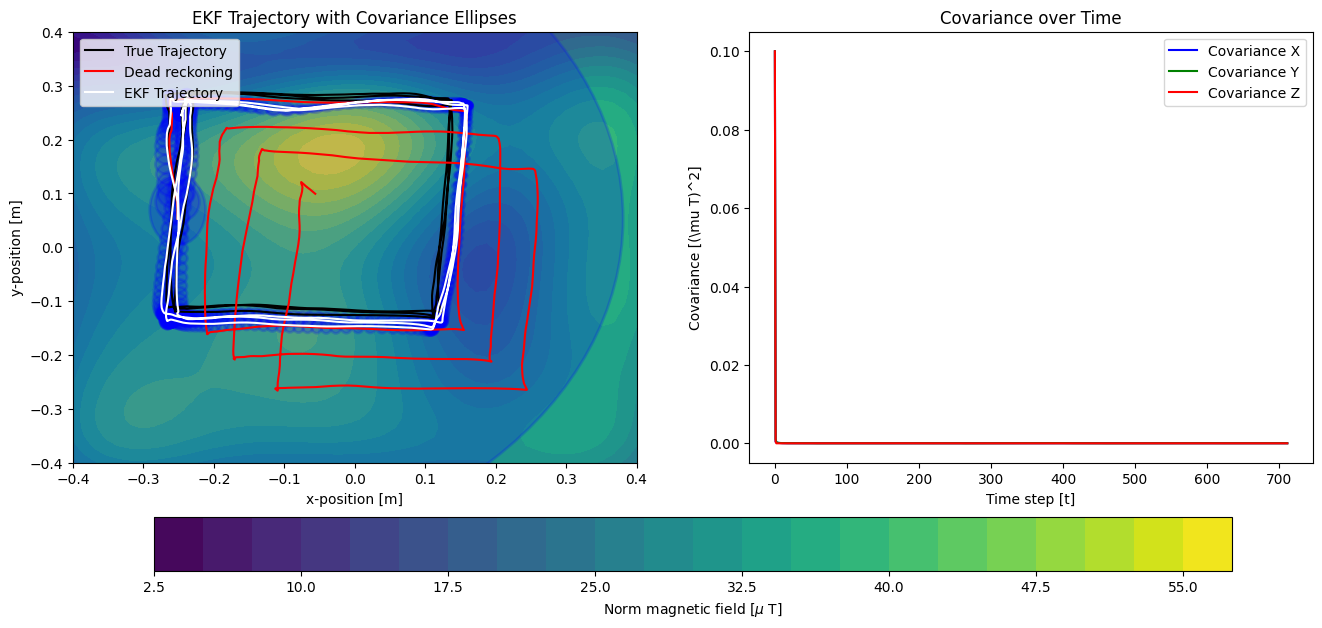

In [205]:
''' DO NOT CHANGE THE CODE BELOW '''
helper.makeExtendedKalmanFilterPlots(deadReckoning, posEstEKF, posCovarianceEKF, modelParameters)

**Discussion**

Typically, the covariance will increase after the dynamicUpdate and then decrease after the measurementUpdate, resulting in a net decrease in our covariance at each time step as we get more measurements and become more certain of our estimate. However, we see large spikes in the covariance around time steps 150, 350, and 550, which corresponds to the agent going around the bottom left corner of the trajectory. In this spot, the magnetic field function is very "flat", or changing very slowly, resulting in a small Jacobian matrix. As a result, our measurements are less meaningful, because they could correspond to many different locations on the map. Therefore, the covariance does not decrease much from the measurementUpdate and we see the covariance increasing over time from the dynamicUpdate. In other locations on the map, the magnetic field changes more quickly, resulting in a larger gradient and more meaningful measurements, causing the covariance to decrease after the measurementUpdate in these areas. 

### UKF implement 

#### Task 1
Fill in the `dynamicUpdateUKF()` function according to the dynamic model given above. 

#### Note:
You do not have to change the inputs and outputs to the given functions.


In [9]:
def dynamicUpdateUKF(position, 
                   deltaPos, 
                   posCov, 
                   motionCovarianceUKF, 
                   modelParameters):
    ''' Dynamic update '''
    position = position + deltaPos    
    posCov = posCov + motionCovarianceUKF

    return position, posCov

#### Task 2

- Complete creating sigma points `createSigmaPoints()` and calculating sigma weights `calculateSigmaWeights()`.
- Fill in the `measurementUpdateUKF()` according to the measurement model given above. 
- You can play around with UT1 and UT2, can you see any obvious differences?


In [169]:
def createSigmaPoints(stateVector, stateCovariance, lamdaWeights, modelParameters):
    ''' Create sigma points '''
    n = 3
    sigmaPoints = np.zeros((3, 2*n+1))
    sigmaPoints[:, 0] = stateVector.flatten()
    for i in range(n):
        sigmaPoints[:, i+1] = stateVector.flatten() + (np.sqrt(n+lamdaWeights))*np.linalg.cholesky(stateCovariance)[:,i]
        sigmaPoints[:, i+n+1] = stateVector.flatten() - (np.sqrt(n+lamdaWeights))*np.linalg.cholesky(stateCovariance)[:,i]

    return sigmaPoints


def calculateSigmaWeights(UTnumber = 1):
    ''' Calculate the weights '''
    n = 3
    if UTnumber == 1:
        '''UT1'''
        lamdaWeights = 3 - n
        add_term = 0
    else:
        '''UT2'''
        lamdaWeights = 1e-6*n - n
        add_term = 3 - 1e-6
    
    weightsMean = np.zeros(2*n+1)
    weightsMean[0] = lamdaWeights/(n+lamdaWeights)
    weightsMean[1:] = 1/(2*(n+lamdaWeights))
    weightsCov = np.zeros(2*n+1)
    weightsCov[0] = weightsMean[0] + add_term
    weightsCov[1:] = 1/(2*(n+lamdaWeights))
    
    return lamdaWeights, weightsMean, weightsCov


def measurementUpdateUKF(position,
                         magnetometerMeasurement,
                         posCovariance,
                         measurementCovarianceUKF,
                         lamdaWeights, 
                         weightsMean, 
                         weightsCovariance,
                         modelParameters):
    
    ''' Measurement update '''
    sigmaPoints = createSigmaPoints(position, posCovariance, lamdaWeights, modelParameters)

    n = 3
    magneticFieldPrediction = GP.makeMagneticFieldPrediction(sigmaPoints, modelParameters) 
    yhat = np.zeros((3,1))
    Cbar = np.zeros((n,n))
    S = np.zeros((n,n))
    for i in range(2*n+1):
        yhat += weightsMean[i]*magneticFieldPrediction[:,i].reshape(3,1)
    
    for i in range(2*n+1):
        Cbar += weightsCovariance[i]*(sigmaPoints[:,i].reshape(3,1) - sigmaPoints[:,0].reshape(3,1))@((magneticFieldPrediction[:,i].reshape(3,1) - yhat).T)
        S += weightsCovariance[i]*(magneticFieldPrediction[:,i].reshape(3,1) - yhat)@((magneticFieldPrediction[:,i].reshape(3,1) - yhat).T)
    S += measurementCovarianceUKF

    K = Cbar@np.linalg.inv(S)
    position = position + K@(magnetometerMeasurement - yhat)
    posCovariance = posCovariance - K@S@K.T

    return position, posCovariance

`unscentedKalmanFilter()` is given as follows. You don't need to change it.

In [170]:
''' DO NOT CHANGE THE CODE BELOW '''
def unscentedKalmanFilter(position, 
                          deltaPos, 
                          magnetometerMeasurement, 
                          posCovariance, 
                          motionCovarianceUKF,
                          measurementCovarianceUKF,
                          lamdaWeights, 
                          weightsMean, 
                          weightsCovariance,
                          modelParameters):

    if modelParameters['NtimeStepUKF'] > 0:
        ''' State update '''
        position, posCovariance = dynamicUpdateUKF(position, 
                                                deltaPos, 
                                                posCovariance, 
                                                motionCovarianceUKF, 
                                                modelParameters)

    ''' Measurement update '''
    position, posCovariance = measurementUpdateUKF(position, 
                                                   magnetometerMeasurement, 
                                                   posCovariance, 
                                                   measurementCovarianceUKF,
                                                   lamdaWeights,
                                                   weightsMean,
                                                   weightsCovariance,
                                                   modelParameters)

    return position, posCovariance



#### Task 3

Be sure to set the **initial position** and the **prior** on it correctly  and a **suitable measurement covariance** as you did in assignment 1.

You could start with the following parameters
- `motionCovarianceUKF` = np.eye(3)*0.001**2 
- `measurementCovarianceUKF` = np.eye(3)*1.5**2

Make sure `posCovarianceUKF` is a 3d tensor with the shape of `[3,3,NtimeSteps]`, to save the position covariances for every time step.
To get better results, you might have to tune these. 

In [189]:

''' Initialize the UKF '''
modelParameters['NtimeStepUKF'] = 0

motionCovarianceUKF = np.eye(3)*0.001**2
measurementCovarianceUKF = np.eye(3)*1.5**2

posEstUKF = np.zeros((3, modelParameters['NtimeSteps']))
posCovarianceUKF = np.zeros((3, 3, modelParameters['NtimeSteps']))
posEstUKF[:,0] = magnetometerInitialPosition.squeeze()
posCovarianceUKF[:,:,0] = np.eye(3)*0.1

lamdaWeights, weightsMean, weightsCovariance = calculateSigmaWeights(1)

''' Run the UKF'''
for timendx in range(modelParameters['NtimeSteps']-1):
    (posEstUKF[:, timendx+1:timendx+2], 
     posCovarianceUKF[:, :, timendx+1]) = unscentedKalmanFilter(posEstUKF[:, timendx:timendx+1], 
                                               deltaMagnetometerPositions[:, timendx:timendx+1], 
                                               magnetometerMeasurements[:, timendx:timendx+1], 
                                               posCovarianceUKF[:, :, timendx],
                                               motionCovarianceUKF,
                                               measurementCovarianceUKF,
                                               lamdaWeights, 
                                               weightsMean, 
                                               weightsCovariance,
                                               modelParameters)
    modelParameters['NtimeStepUKF'] += 1



#### discussion

Elaborate on the effects of tuning the different variables:

- `motionCovarianceUKF`
- `measurementCovarianceUKF`
- The initial posiiton covariance `posCovarianceUKF[:, :, 0]`

Is it different from tuning the variables for the EKF?

### compare EKF and UKF
#### Visualize the output

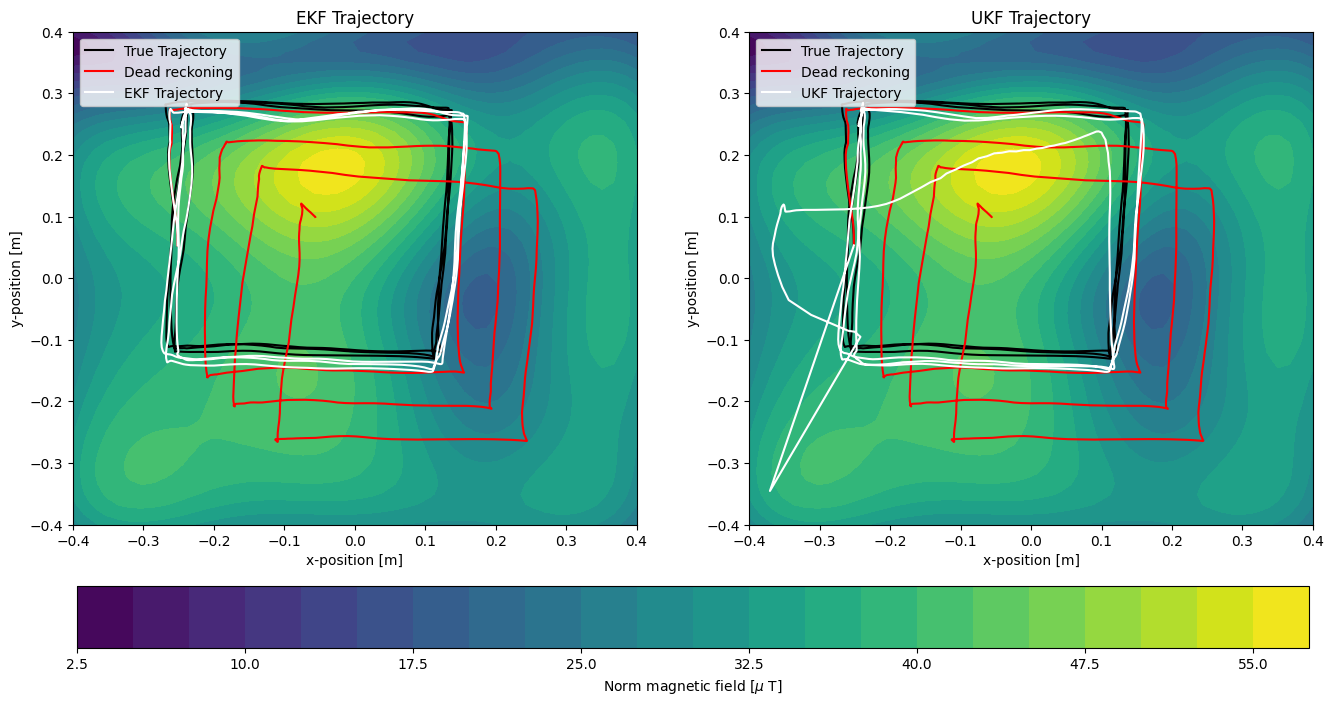

In [190]:
helper.makeKalmanFilterPlots(deadReckoning, posEstEKF, posEstUKF, modelParameters)

#### Discussion
Elaborate on the two plots.
- Compare the results from the UKF with the EKF? Does one provide better results? Elaborate!

The UKF and the EKF perform almost identically. The EKF seems to perform slightly better in the top left corner, but it's not a big difference. The EKF also runs a little bit faster because it doesn't need to perform calculations for 2n+1 sigma points, just one point. 

- Comment on the reason for choosing either EKF, UKF of PF for this non-linear estimation problem. Also relate this to the results from assignment 1. 

EKF is the best choice for this problem, as it performs similarly well to the UKF but requires slightly less computational effort. The EKF was also simpler to code and easier to tune, while the UKF is more sensitive to various parameters, such as the spread of the sigma points and the initial covariance. 

The EKF is much more computationally efficient than the PF. To see similar results with the PF, we need > 500 particles, which takes over 20s to run. Meanwhile, the EKF achieves the same results in less than 0.1s. Although the PF best captures nonlinearity, we need a very high number of particles to see this benefit, which requires quite a bit more computation. In our case, the measurement model exhibits only moderate linearity, so the EKF/UKF are better suited for this problem. 

- In what type of estimation problems would you expect to see very different results for the EKF, UKF and PF? 

When the model is highly nonlinear and we're able to use a lot of particles, we expect the PF to perform better because it is able to best capture this nonlinearity. In this case, the EKF will not perform as well because the linear approximation at each time step will not be very good. The particle filter will also perform better than the EKF if we have non-Gaussian noise, as the EKF assumes that the noise is Gaussian. The UKF can also perform well if there's non-Gaussian noise, but the noise still needs to be approximately Gaussian, because the spread of sigma points based on the mean and covariance. So, if the noise is multi-modal or has heavy tails, the sigma points might not do a good job representing the spread of possibilities.   

In summary, the 3 algorithms will behave very differently if:
- we cannot use a lot of particles
- the model is highly non-linear
- the noise is very non-Gaussian (cannot be approximated well with a Gaussian distribution)

<!-- TODO: DO WE NEED THE "PLAY AROUND WITH DIFFERENT PARAMETERS SESSION AS THE FIRST ASSIGMENT?" -->